In [8]:
import os,sys

sys.path.insert(0,'/mnt/shenwanxiang/Research/COMPASS_main/')


In [9]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from umap import UMAP
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap, MDS, LocallyLinearEmbedding
import os
sns.set(style = 'white', font_scale=1.5)

In [11]:
%matplotlib inline

In [12]:
from compass import loadcompass
from compass.tokenizer import CONCEPT_palette
from compass.tokenizer import CANCER_CODE


CONCEPT_palette = pd.DataFrame([CONCEPT_palette]).T.reset_index().sort_index(ascending=False).set_index('index')[0].to_dict()

hue_order = CONCEPT_palette.keys()
hue_color = CONCEPT_palette.values()

In [13]:
pretrainer = loadcompass('compass_run/PT_v100//pretrainer.pt') #

## TCGA data

In [14]:
data_path = './data'
df_tpm = pd.read_pickle(os.path.join(data_path,  'TCGA', 'TCGA.TPM.TABLE'))
dfl = pd.read_pickle(os.path.join(data_path, 'TCGA', 'TCGA.PATIENT.TABLE'))

dfcx = dfl.cancer_type.apply(lambda x:x.replace('TCGA-', '')).map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
dfg, dfc = pretrainer.project(dfcx,  batch_size= 128)

pid = dfc.index.map(lambda x:x.split('$$')[0])
fid = dfc.index.map(lambda x:x.split('$$')[1])
df = pd.DataFrame(index=dfc.index)
df['bcr_patient_barcode'] = pid
df['feature_name'] = fid
df = df.join(dfc)
df = df.sort_values(['feature_name', 'bcr_patient_barcode'])

tcga = df['bcr_patient_barcode'].map(dfl['cancer_type'].apply(lambda x:x.split('-')[1])).to_frame(name='cancer_type')
tcga['domain'] = 'TCGA'
tcga_dfc = tcga.join(df)

100%|#################################################################################| 80/80 [00:13<00:00,  5.88it/s]


In [15]:
tcga_dfc.head()

,cancer_type,domain,bcr_patient_barcode,feature_name,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,...,channel_22,channel_23,channel_24,channel_25,channel_26,channel_27,channel_28,channel_29,channel_30,channel_31
TCGA-02-0047$$Adipocyte,GBM,TCGA,TCGA-02-0047,Adipocyte,0.444477,0.094672,-0.531831,1.607502,0.233175,-0.249958,...,0.651075,0.001314,0.141338,0.090224,0.571750,-0.638501,0.529315,0.826580,-0.368475,-0.307705
TCGA-02-0055$$Adipocyte,GBM,TCGA,TCGA-02-0055,Adipocyte,0.296538,0.033896,-0.402495,1.494289,0.096844,-0.191919,...,0.459270,-0.017269,0.038959,0.296413,0.568397,-0.222692,0.492854,0.882311,-0.492096,-0.067420
TCGA-02-2483$$Adipocyte,GBM,TCGA,TCGA-02-2483,Adipocyte,0.351540,0.194064,-0.517835,1.443118,0.097430,-0.257961,...,0.333737,0.089121,0.040831,0.440864,0.447510,-0.057148,0.424965,0.780232,-0.438376,-0.200273
TCGA-02-2485$$Adipocyte,GBM,TCGA,TCGA-02-2485,Adipocyte,0.326845,0.218359,-0.577622,1.429995,0.199230,-0.227283,...,0.626770,0.090315,0.039196,0.169710,0.470919,-0.294849,0.512518,0.721112,-0.349306,-0.282137
TCGA-02-2486$$Adipocyte,GBM,TCGA,TCGA-02-2486,Adipocyte,0.442021,0.013176,-0.374286,1.515235,0.119579,-0.106786,...,0.515036,-0.041794,0.144483,0.569048,0.392967,-0.319308,0.564895,0.690565,-0.545927,-0.344708


## ITRP data

In [16]:
df_tpm = pd.read_pickle(os.path.join(data_path,  'ITRP', 'ITRP.TPM.TABLE'))[pretrainer.feature_name]
dfl = pd.read_pickle(os.path.join(data_path, 'ITRP', 'ITRP.PATIENT.TABLE'))

dfcx = dfl.cancer_type.map(CANCER_CODE).to_frame('cancer_code').join(df_tpm)
dfg, dfc = pretrainer.project(dfcx,  batch_size= 128)

pid = dfc.index.map(lambda x:x.split('$$')[0])
fid = dfc.index.map(lambda x:x.split('$$')[1])
df = pd.DataFrame(index=dfc.index)
df['Index'] = pid
df['feature_name'] = fid
df = df.join(dfc)
df = df.sort_values(['feature_name', 'Index'])
df = df.rename(columns = {'Index':'bcr_patient_barcode'})
itrp = df['bcr_patient_barcode'].map(dfl['cancer_type']).to_frame(name='cancer_type')
itrp['domain'] = 'ITRP'
itrp_dfc = itrp.join(df)


100%|###################################################################################| 9/9 [00:01<00:00,  5.33it/s]


In [17]:
itrp_dfc.head()

,cancer_type,domain,bcr_patient_barcode,feature_name,channel_0,channel_1,channel_2,channel_3,channel_4,channel_5,...,channel_22,channel_23,channel_24,channel_25,channel_26,channel_27,channel_28,channel_29,channel_30,channel_31
102T-Tumor-SM-BZ9XL$$Adipocyte,SKCM,ITRP,102T-Tumor-SM-BZ9XL,Adipocyte,0.199734,0.097486,-0.235600,1.778175,0.406122,-0.212877,...,0.715577,0.132219,-0.001234,0.297995,0.530349,0.192999,0.159836,0.828278,-0.418069,-0.078457
107T-Tumor-SM-BZ9WD$$Adipocyte,SKCM,ITRP,107T-Tumor-SM-BZ9WD,Adipocyte,0.413001,0.033866,-0.361329,1.588933,0.319708,-0.137121,...,0.834413,0.280939,0.010832,0.272654,0.569261,0.040417,0.185025,0.980233,-0.437547,0.049655
10_PD1_PRE$$Adipocyte,SKCM,ITRP,10_PD1_PRE,Adipocyte,0.277186,0.298982,-0.268495,1.710052,0.297267,-0.528744,...,0.480052,-0.152727,0.048559,0.397542,0.600817,0.250605,0.308127,1.248409,-0.377985,0.097409
10_ipiPD1_PRE$$Adipocyte,SKCM,ITRP,10_ipiPD1_PRE,Adipocyte,0.186439,0.082788,-0.398990,1.527671,0.217414,-0.370401,...,0.625107,-0.032724,0.012452,-0.050009,0.692401,-0.013977,0.119659,1.238372,-0.237247,0.077813
115T-Tumor-SM-BZ9WG$$Adipocyte,SKCM,ITRP,115T-Tumor-SM-BZ9WG,Adipocyte,0.361840,0.141748,-0.403613,1.721518,0.357834,-0.164780,...,0.820033,0.224646,0.023525,0.346752,0.617529,0.063377,0.136060,0.843135,-0.367969,-0.064767


In [18]:
dfc = tcga_dfc._append(itrp_dfc)

## PCA embedding

In [19]:
data = tcga_dfc[tcga_dfc.columns[-32:]].values
mp = PCA(n_components = 2) #
mp = mp.fit(data)
df2d = mp.transform(dfc[dfc.columns[-32:]].values)
df_pca2d  = pd.DataFrame(df2d, index=dfc.index, columns = ['PCA1', 'PCA2'])

## UMAP embedding

In [20]:


mp = UMAP(n_components = 2, n_neighbors = 300, n_epochs = 1000, min_dist=0.8, 
           repulsion_strength=3.0, spread=2.0,init = "spectral", #metric='cosine', 
          random_state = 42,  verbose=1 ) # 

# reducer = umap.UMAP(
#     n_neighbors=10,
#     min_dist=0.3,
#     spread=5.0,
#     repulsion_strength=8.0,
#     negative_sample_rate=40,
#     metric="cosine",
#     n_epochs=3000,
#     random_state=42,
# )

mp = mp.fit(data)
umap2d = mp.transform(dfc[dfc.columns[-32:]].values)
df_umap2d  = pd.DataFrame(umap2d, index=dfc.index, columns = ['UMAP1', 'UMAP2'])

UMAP(min_dist=0.8, n_epochs=1000, n_jobs=1, n_neighbors=300, random_state=42, repulsion_strength=3.0, spread=2.0, verbose=1)
Tue May 12 00:14:42 2026 Construct fuzzy simplicial set
Tue May 12 00:14:42 2026 Finding Nearest Neighbors
Tue May 12 00:14:42 2026 Building RP forest with 38 trees
Tue May 12 00:14:52 2026 NN descent for 19 iterations
	 1  /  19
	 2  /  19
	 3  /  19
	Stopping threshold met -- exiting after 3 iterations
Tue May 12 00:30:01 2026 Finished Nearest Neighbor Search
Tue May 12 00:30:53 2026 Construct embedding


Epochs completed:   0%|            0/1000 [00:00]

	completed  0  /  1000 epochs
	completed  100  /  1000 epochs
	completed  200  /  1000 epochs
	completed  300  /  1000 epochs
	completed  400  /  1000 epochs
	completed  500  /  1000 epochs
	completed  600  /  1000 epochs
	completed  700  /  1000 epochs
	completed  800  /  1000 epochs
	completed  900  /  1000 epochs
Tue May 12 02:05:56 2026 Finished embedding
Tue May 12 02:11:01 2026 Worst tree score: 0.98583277
Tue May 12 02:11:01 2026 Mean tree score: 0.98692960
Tue May 12 02:11:01 2026 Best tree score: 0.98786514
Tue May 12 02:11:16 2026 Forward diversification reduced edges from 131373600 to 4639325
Tue May 12 02:11:20 2026 Reverse diversification reduced edges from 4639325 to 4639325
Tue May 12 02:11:23 2026 Degree pruning reduced edges from 6049570 to 6049570
Tue May 12 02:11:23 2026 Resorting data and graph based on tree order
Tue May 12 02:11:23 2026 Building and compiling search function


Epochs completed:   0%|            0/333 [00:00]

	completed  0  /  333 epochs
	completed  33  /  333 epochs
	completed  66  /  333 epochs
	completed  99  /  333 epochs
	completed  132  /  333 epochs
	completed  165  /  333 epochs
	completed  198  /  333 epochs
	completed  231  /  333 epochs
	completed  264  /  333 epochs
	completed  297  /  333 epochs
	completed  330  /  333 epochs


In [21]:
df2d = dfc[['cancer_type', 'domain', 
            'bcr_patient_barcode', 'feature_name']].join(df_pca2d).join(df_umap2d)

In [22]:
df2d.to_pickle('./results/emb.pkl')

In [23]:
dpi = 96

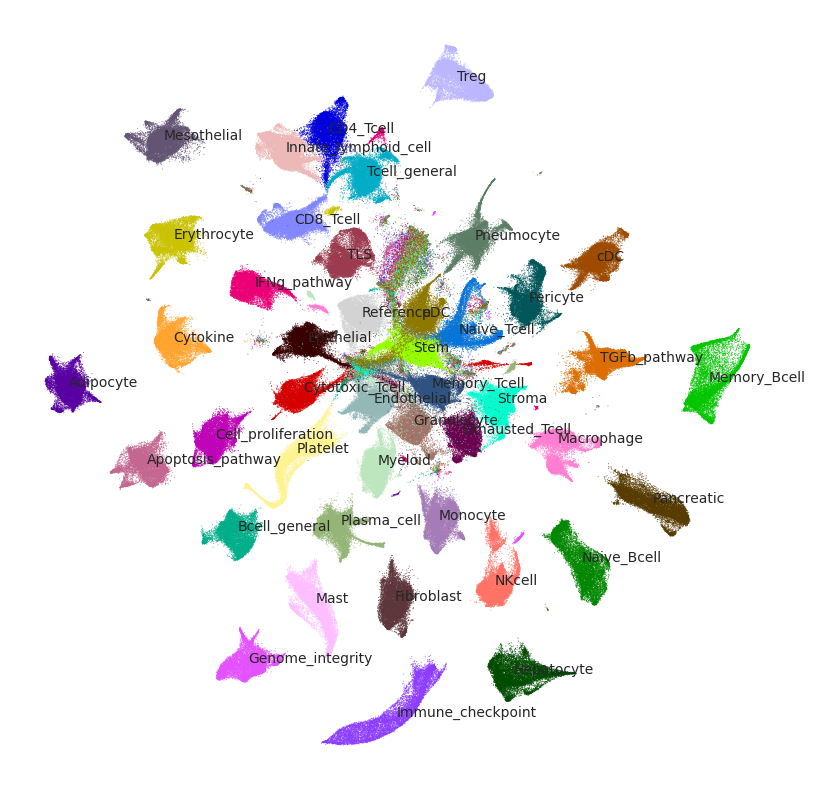

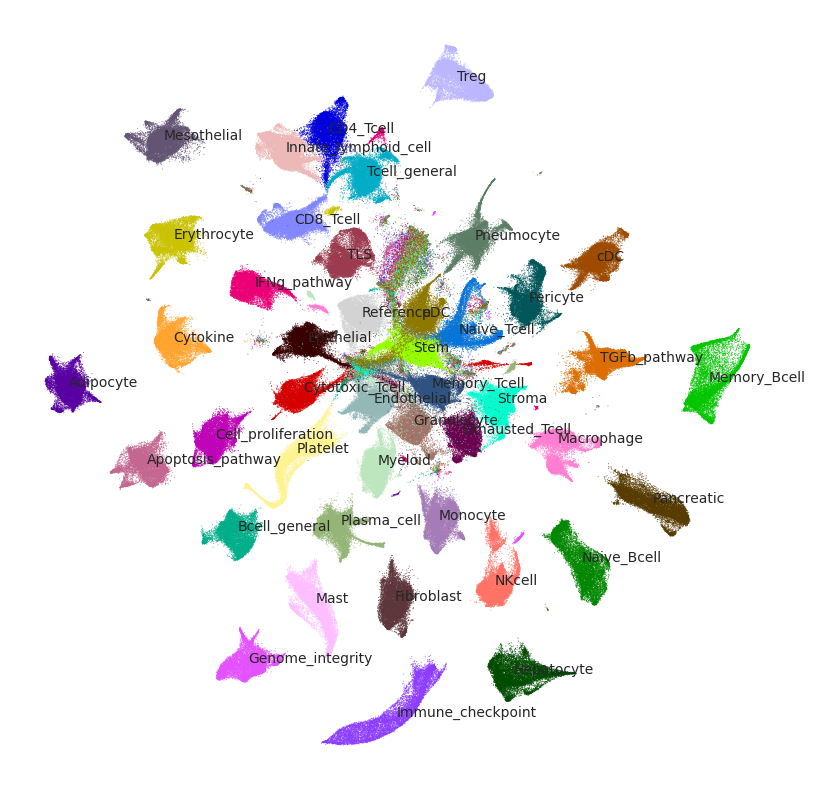

In [24]:
dfp = df2d[df2d.domain == 'TCGA']
fig, ax = plt.subplots(figsize=(10, 10))

x = 'UMAP1'
y = 'UMAP2'
hue = 'feature_name'

sns.scatterplot(data = dfp, x = x, y = y, hue = hue,  alpha = 0.8,
                linewidth=0.0, hue_order = hue_order, palette=hue_color, s = 0.5, 
                 ax=ax, legend=False)

mean = dfp.groupby(hue)[[x,y]].median()
for name in mean.index:
    s = mean.loc[name]
    ax.text(s[x], s[y], name,  fontdict={'fontsize':10})

ax.tick_params(bottom='on', left='off',  labelleft='on', labelbottom='on', pad=-.6,)
ax.set_xlabel('')
ax.set_ylabel('')

plt.axis('off')

fig.savefig('./results/cell_TCGA_UMAP_unlabelled.jpg', bbox_inches ='tight', dpi=dpi)
fig

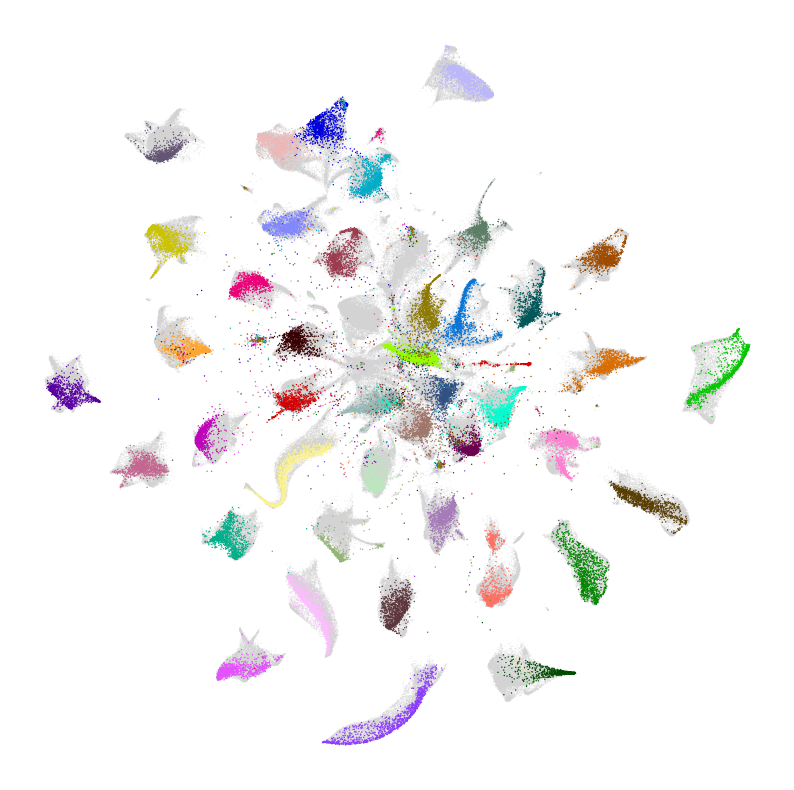

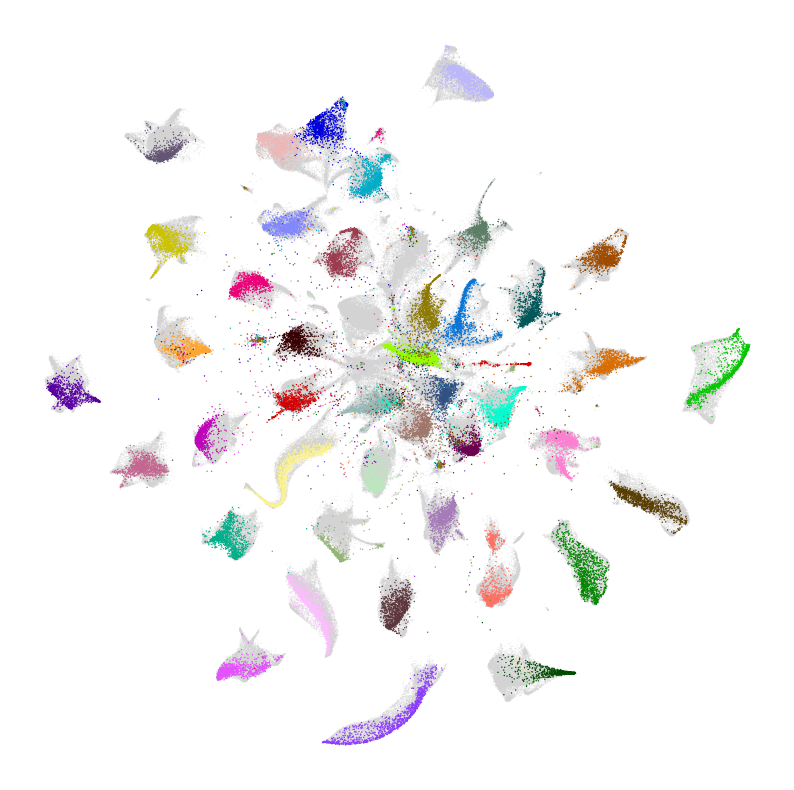

In [25]:
dfp1 = df2d[df2d.domain == 'TCGA']
dfp2 = df2d[df2d.domain == 'ITRP']

background_color = {i:'#d3d3d3' for i in hue_order}
fig, ax = plt.subplots(figsize=(10, 10))

x = 'UMAP1'
y = 'UMAP2'
hue = 'feature_name'

sns.scatterplot(data = dfp1, x = x, y = y, hue = hue,  alpha = 0.5,
                linewidth=0.0, hue_order = hue_order, palette=background_color, s = 0.5, 
                 ax=ax, legend=False)

sns.scatterplot(data = dfp2, x = x, y = y, hue = hue,  alpha = 1,
                linewidth=0.0, hue_order = hue_order, palette=hue_color, s = 1, 
                 ax=ax, legend=False)

# mean = dfp2.groupby(hue)[[x,y]].median()
# for name in mean.index:
#     s = mean.loc[name]
#     ax.text(s[x], s[y], name,  fontdict={'fontsize':8})

ax.tick_params(bottom='on', left='off',  labelleft='on', labelbottom='on', pad=-.6,)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')

plt.axis('off')

fig.savefig('./results/cell_overlay_UMAP_labelled.jpg', bbox_inches ='tight', dpi=dpi)
fig

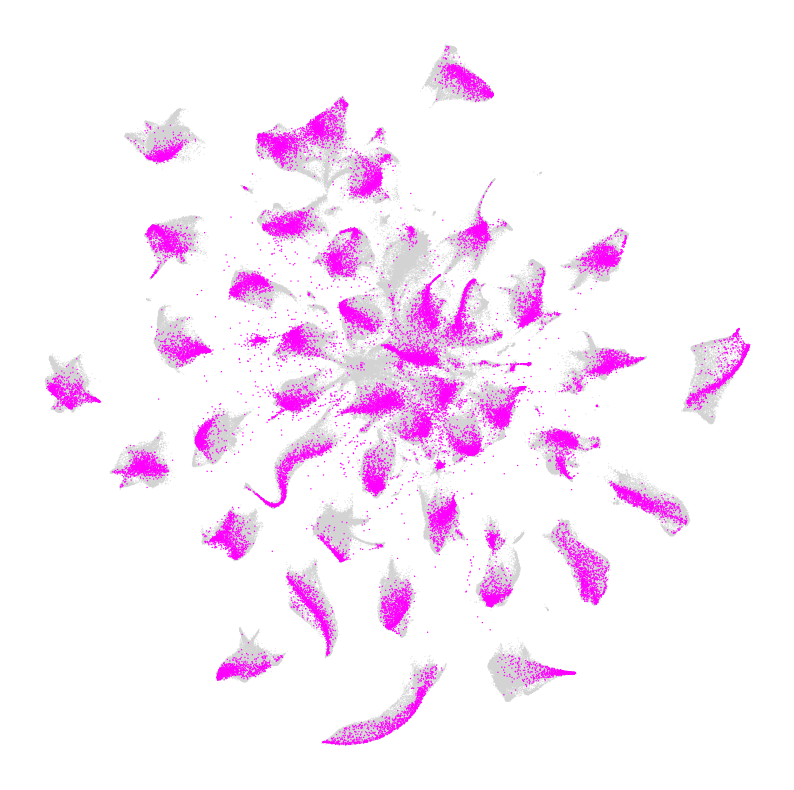

In [26]:
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches


def add_legend(ax, markersize = 1):
    handles = []
    point1 = Line2D([0], [0], label='TCGA', marker='o', markersize=markersize, 
             markeredgecolor=list(background_color.values())[0], linestyle='',
                   markerfacecolor=list(background_color.values())[0],)
    
    point2 = Line2D([0], [0], label='ITRP', marker='o', markersize=markersize, 
             markeredgecolor=list(overlay_color.values())[0], linestyle='',
                   markerfacecolor=list(overlay_color.values())[0],)
    
    # add manual symbols to auto legend
    handles.extend([point1, point2])
    
    ax.legend(handles=handles, numpoints=5)
    

dfp1 = df2d[df2d.domain == 'TCGA']
dfp2 = df2d[df2d.domain == 'ITRP']

background_color = {i:'#d3d3d3' for i in hue_order}
overlay_color = {i:'#ff00ff' for i in hue_order}

fig, ax = plt.subplots(figsize=(10, 10))

x = 'UMAP1'
y = 'UMAP2'
hue = 'feature_name'

sns.scatterplot(data = dfp1, x = x, y = y, hue = hue,  alpha = 0.8,
                linewidth=0.0, hue_order = hue_order, palette=background_color, s = 0.5, 
                 ax=ax, legend=False)

sns.scatterplot(data = dfp2, x = x, y = y, hue = hue,  alpha = 1,
                linewidth=0.0, hue_order = hue_order, palette=overlay_color, s = 1, 
                 ax=ax, legend=False)

#add_legend(ax)

# mean = dfp1.groupby(hue)[[x,y]].median()
# for name in mean.index:
#     s = mean.loc[name]
#     ax.text(s[x], s[y], name,  fontdict={'fontsize':8})

ax.tick_params(bottom='on', left='off',  labelleft='on', labelbottom='on', pad=-.6,)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')

plt.axis('off')

fig.savefig('./results/cell_overlay_UMAP_unlabelled.jpg', bbox_inches ='tight', dpi=dpi)